DATASET OVERVIEW
Customers: 2400 rows, 9 columns
Orders: 10009 rows, 10 columns
Support Tickets: 1921 rows, 8 columns
Web Events: 2400 rows, 10 columns
Churn Labels: 2400 rows, 4 columns
RFM Snapshot: 2400 rows, 29 columns
Interventions: 2400 rows, 5 columns
MISSING VALUES ANALYSIS - customers.csv
      Column  Missing_Count  Missing_Percent
loyalty_tier           1386        57.750000
   skin_type            401        16.708333

LOYALTY_TIER ANALYSIS
loyalty_tier
NaN         1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64

Customers without loyalty tier: 1386 (57.8%)

SKIN_TYPE ANALYSIS
skin_type
Oily           420
Dry            405
NaN            401
Sensitive      395
Combination    390
Normal         389
Name: count, dtype: int64
ORDERS DATA QUALITY
Orders with _DUP suffix: 12
Post-snapshot orders (NOT for features): 1872

Gross Amount Statistics:
count    10009.000000
mean       743.898504
std        600.564068
min        149.000000
25%        4

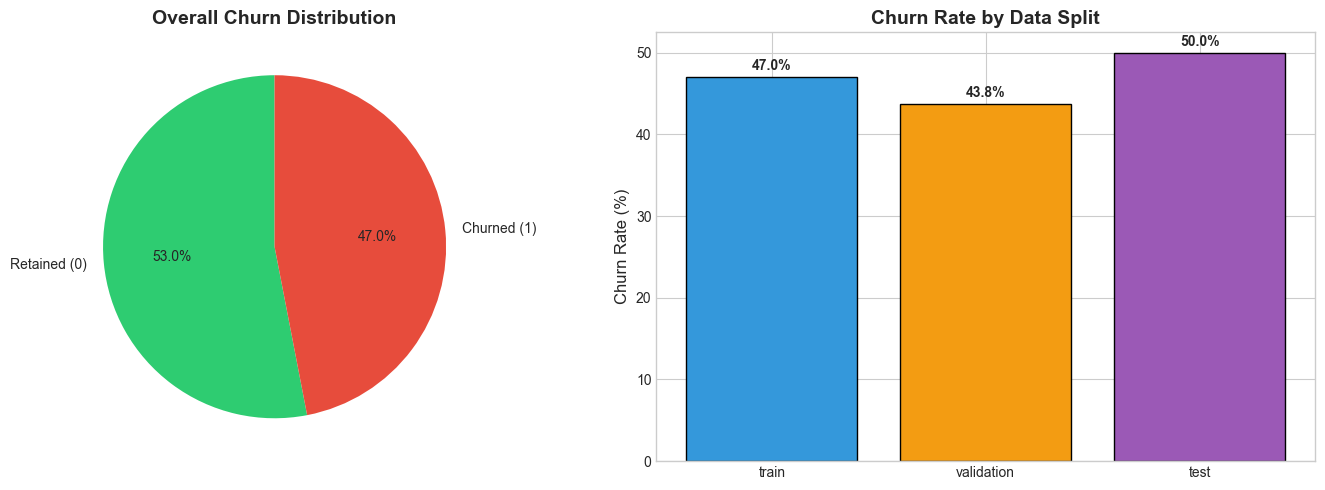

posx and posy should be finite values


TEMPORAL ANALYSIS
Churn Rate by Signup Month:
              Signups  Churn_Rate
signup_month                     
2024-01           116   49.137931
2024-02           106   51.886792
2024-03           120   55.000000
2024-04           124   47.580645
2024-05           117   45.299145
2024-06           125   47.200000
2024-07           121   56.198347
2024-08           114   42.982456
2024-09           111   49.549550
2024-10           133   57.894737
2024-11           127   51.181102
2024-12           116   49.137931
2025-01           127   51.181102
2025-02           104   57.692308
2025-03           112   48.214286
2025-04           110   53.636364
2025-05           114   49.122807
2025-06           100   38.000000
2025-07           116   31.034483
2025-08           120   26.666667
2025-09            67   10.447761

CHURN BY ACQUISITION CHANNEL
                     Total  Churn_Rate
acquisition_channel                   
Google Search          466   50.429185
Instagram              51

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


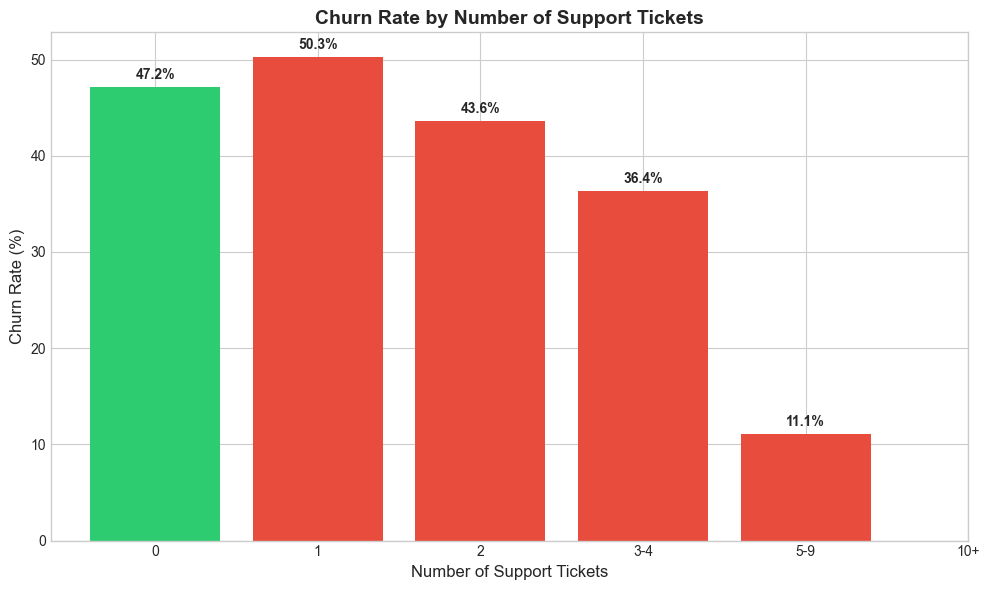


TICKET SENTIMENT ANALYSIS
Avg sentiment score - Retained customers: -0.436
Avg sentiment score - Churned customers: -0.447
WEB ACTIVITY ANALYSIS

Web Metrics Comparison (Churned vs Retained):
--------------------------------------------------
sessions_30d              | Retained:     6.73 | Churned:     4.02
product_views_30d         | Retained:    28.38 | Churned:    16.97
cart_adds_30d             | Retained:     1.95 | Churned:     1.13
wishlist_adds_30d         | Retained:     1.06 | Churned:     0.59
abandoned_carts_30d       | Retained:     0.85 | Churned:     0.47
email_opens_30d           | Retained:     2.95 | Churned:     2.30
campaign_clicks_30d       | Retained:     0.74 | Churned:     0.55
last_visit_days_ago       | Retained:     9.77 | Churned:    26.55


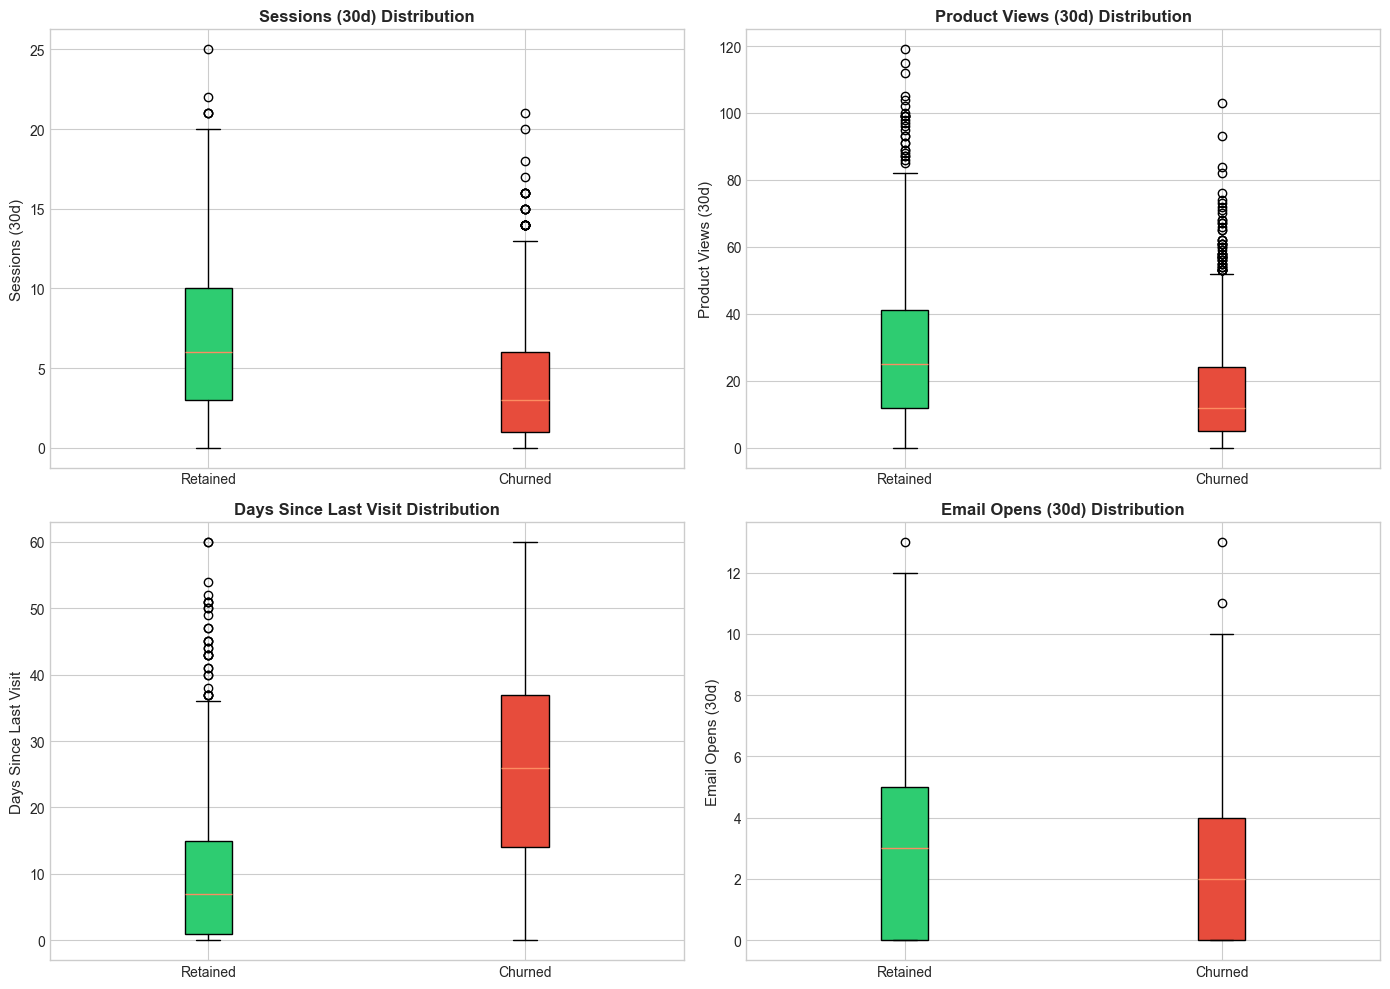

KEY BUSINESS INSIGHTS

Churn Rate:
  → 47.0% of customers churned in the 60-day window

Support Impact:
  → Customers with tickets churn at 46.8% vs 47.2% without tickets

Sentiment:
  → Churned customers had 0.010 lower average sentiment score

Recency:
  → Churned customers last visited 27 days ago vs 10 days for retained

Best Channel:
  → Lowest churn channel: Organic (39.8%)

Worst Channel:
  → Highest churn channel: Google Search (50.4%)


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Load all datasets
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
support_tickets = pd.read_csv("data/support_tickets.csv")
web_events = pd.read_csv("data/web_events_snapshot.csv")
churn_labels = pd.read_csv("data/churn_labels.csv")
rfm_snapshot = pd.read_csv("data/rfm_modeling_snapshot.csv")
intervention = pd.read_csv("data/intervention_history.csv")

# Display basic info
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Customers: {customers.shape[0]} rows, {customers.shape[1]} columns")
print(f"Orders: {orders.shape[0]} rows, {orders.shape[1]} columns")
print(f"Support Tickets: {support_tickets.shape[0]} rows, {support_tickets.shape[1]} columns")
print(f"Web Events: {web_events.shape[0]} rows, {web_events.shape[1]} columns")
print(f"Churn Labels: {churn_labels.shape[0]} rows, {churn_labels.shape[1]} columns")
print(f"RFM Snapshot: {rfm_snapshot.shape[0]} rows, {rfm_snapshot.shape[1]} columns")
print(f"Interventions: {intervention.shape[0]} rows, {intervention.shape[1]} columns")
## 1.2 Data Quality Audit

### Missing Values Analysis

# Analyze missing values in customers.csv
print("="*60)
print("MISSING VALUES ANALYSIS - customers.csv")
print("="*60)

customers_missing = customers.isnull().sum()
customers_missing_pct = (customers_missing / len(customers)) * 100
missing_df = pd.DataFrame({
    'Column': customers_missing.index,
    'Missing_Count': customers_missing.values,
    'Missing_Percent': customers_missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_df.to_string(index=False))

# loyalty_tier analysis
print("\n" + "="*60)
print("LOYALTY_TIER ANALYSIS")
print("="*60)
print(customers['loyalty_tier'].value_counts(dropna=False))
print(f"\nCustomers without loyalty tier: {customers['loyalty_tier'].isna().sum()} ({customers['loyalty_tier'].isna().mean()*100:.1f}%)")

# skin_type analysis
print("\n" + "="*60)
print("SKIN_TYPE ANALYSIS")
print("="*60)
print(customers['skin_type'].value_counts(dropna=False))
### Orders Data Quality Issues

# Check for duplicate-like records (_DUP suffix)
print("="*60)
print("ORDERS DATA QUALITY")
print("="*60)

dup_orders = orders[orders['order_id'].str.contains('_DUP', na=False)]
print(f"Orders with _DUP suffix: {len(dup_orders)}")

# Check for post-snapshot orders (leakage risk)
orders['order_date'] = pd.to_datetime(orders['order_date'])
snapshot_date = pd.to_datetime('2025-09-30')
post_snapshot = orders[orders['order_date'] > snapshot_date]
print(f"Post-snapshot orders (NOT for features): {len(post_snapshot)}")

# Check for outlier order values
print(f"\nGross Amount Statistics:")
print(orders['gross_amount'].describe())
outliers = orders[orders['gross_amount'] > 10000]
print(f"\nOrders with gross_amount > 10,000: {len(outliers)}")
print("\nTop 5 outlier orders:")
print(outliers.nlargest(5, 'gross_amount')[['order_id', 'gross_amount', 'customer_id', 'order_date']])

# Check missing ratings
missing_ratings = orders['rating'].isna().sum()
print(f"\nMissing ratings: {missing_ratings} ({missing_ratings/len(orders)*100:.1f}%)")
## 1.3 Churn Rate Analysis

# Churn rate by split
print("="*60)
print("CHURN RATE ANALYSIS")
print("="*60)

churn_by_split = churn_labels.groupby('split')['churn_next_60d'].agg(['count', 'mean'])
churn_by_split.columns = ['Total_Customers', 'Churn_Rate']
churn_by_split['Churn_Rate'] = churn_by_split['Churn_Rate'] * 100
print(churn_by_split)

# Overall churn rate
overall_churn = churn_labels['churn_next_60d'].mean() * 100
print(f"\nOverall churn rate: {overall_churn:.1f}%")

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = churn_labels['churn_next_60d'].value_counts()
axes[0].pie(churn_counts.values, labels=['Retained (0)', 'Churned (1)'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart by split
splits = ['train', 'validation', 'test']
churn_rates = [churn_labels[churn_labels['split']==s]['churn_next_60d'].mean()*100 for s in splits]
colors_churn = ['#3498db', '#f39c12', '#9b59b6']
bars = axes[1].bar(splits, churn_rates, color=colors_churn, edgecolor='black')
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1].set_title('Churn Rate by Data Split', fontsize=14, fontweight='bold')
for bar, rate in zip(bars, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
## 1.4 Temporal Analysis (Seasonality)

# Analyze signup dates and potential seasonal patterns
print("="*60)
print("TEMPORAL ANALYSIS")
print("="*60)

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
customers['signup_month'] = customers['signup_date'].dt.to_period('M')

# Join churn data
customers_with_churn = customers.merge(churn_labels[['customer_id', 'churn_next_60d']], on='customer_id')

# Churn rate by signup month
monthly_churn = customers_with_churn.groupby('signup_month')['churn_next_60d'].agg(['count', 'mean'])
monthly_churn.columns = ['Signups', 'Churn_Rate']
monthly_churn['Churn_Rate'] = monthly_churn['Churn_Rate'] * 100

print("Churn Rate by Signup Month:")
print(monthly_churn.to_string())

# Analyze churn by acquisition channel
print("\n" + "="*60)
print("CHURN BY ACQUISITION CHANNEL")
print("="*60)

channel_churn = customers_with_churn.groupby('acquisition_channel')['churn_next_60d'].agg(['count', 'mean'])
channel_churn.columns = ['Total', 'Churn_Rate']
channel_churn['Churn_Rate'] = channel_churn['Churn_Rate'] * 100
channel_churn = channel_churn.sort_values('Churn_Rate', ascending=False)
print(channel_churn.to_string())

## 1.5 Support Tickets Impact on Churn


# Analyze support tickets impact on churn
print("="*60)
print("SUPPORT TICKETS IMPACT ON CHURN")
print("="*60)

# Count tickets per customer
ticket_counts = support_tickets.groupby('customer_id').size().reset_index(name='ticket_count')
ticket_counts['has_ticket'] = 1

# Merge with churn data
churn_with_tickets = churn_labels.merge(ticket_counts[['customer_id', 'ticket_count']], 
                                         on='customer_id', how='left')
churn_with_tickets['ticket_count'] = churn_with_tickets['ticket_count'].fillna(0)
churn_with_tickets['has_ticket'] = churn_with_tickets['ticket_count'] > 0

# Churn rate by ticket presence
print("\nChurn Rate by Ticket Presence:")
ticket_presence_churn = churn_with_tickets.groupby('has_ticket')['churn_next_60d'].mean() * 100
print(f"With tickets: {ticket_presence_churn[True]:.1f}%")
print(f"Without tickets: {ticket_presence_churn[False]:.1f}%")

# Churn rate by number of tickets
ticket_bins = [0, 1, 2, 3, 5, 10, float('inf')]
ticket_labels = ['0', '1', '2', '3-4', '5-9', '10+']
churn_with_tickets['ticket_bin'] = pd.cut(churn_with_tickets['ticket_count'], 
                                            bins=ticket_bins, labels=ticket_labels, right=False)

bin_churn = churn_with_tickets.groupby('ticket_bin')['churn_next_60d'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(bin_churn)), bin_churn.values, color=['#2ecc71' if i==0 else '#e74c3c' for i in range(len(bin_churn))])
ax.set_xticks(range(len(bin_churn)))
ax.set_xticklabels(bin_churn.index)
ax.set_xlabel('Number of Support Tickets', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Churn Rate by Number of Support Tickets', fontsize=14, fontweight='bold')
for bar, rate in zip(bars, bin_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('ticket_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyze sentiment of tickets for churned vs retained
print("\n" + "="*60)
print("TICKET SENTIMENT ANALYSIS")
print("="*60)

tickets_with_churn = support_tickets.merge(churn_labels[['customer_id', 'churn_next_60d']], on='customer_id')
sentiment_by_churn = tickets_with_churn.groupby('churn_next_60d')['sentiment_score'].mean()
print(f"Avg sentiment score - Retained customers: {sentiment_by_churn[0]:.3f}")
print(f"Avg sentiment score - Churned customers: {sentiment_by_churn[1]:.3f}")

## 1.6 Web Activity Analysis


# Analyze web activity patterns
print("="*60)
print("WEB ACTIVITY ANALYSIS")
print("="*60)

web_with_churn = web_events.merge(churn_labels[['customer_id', 'churn_next_60d']], on='customer_id')

# Compare web metrics between churned and retained
web_metrics = ['sessions_30d', 'product_views_30d', 'cart_adds_30d', 
               'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 
               'campaign_clicks_30d', 'last_visit_days_ago']

print("\nWeb Metrics Comparison (Churned vs Retained):")
print("-"*50)
for metric in web_metrics:
    retained_mean = web_with_churn[web_with_churn['churn_next_60d']==0][metric].mean()
    churned_mean = web_with_churn[web_with_churn['churn_next_60d']==1][metric].mean()
    print(f"{metric:25s} | Retained: {retained_mean:8.2f} | Churned: {churned_mean:8.2f}")

# Visualize key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = [('sessions_30d', 'Sessions (30d)'), 
                   ('product_views_30d', 'Product Views (30d)'),
                   ('last_visit_days_ago', 'Days Since Last Visit'),
                   ('email_opens_30d', 'Email Opens (30d)')]

for idx, (metric, title) in enumerate(metrics_to_plot):
    row, col = idx // 2, idx % 2
    data_to_plot = [web_with_churn[web_with_churn['churn_next_60d']==0][metric].values,
                    web_with_churn[web_with_churn['churn_next_60d']==1][metric].values]
    bp = axes[row, col].boxplot(data_to_plot, labels=['Retained', 'Churned'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
    axes[row, col].set_ylabel(title, fontsize=11)
    axes[row, col].set_title(f'{title} Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('web_activity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.7 Key Business Insights


# Compile key insights
print("="*60)
print("KEY BUSINESS INSIGHTS")
print("="*60)

insights = {
    "Churn Rate": f"{overall_churn:.1f}% of customers churned in the 60-day window",
    "Support Impact": f"Customers with tickets churn at {ticket_presence_churn[True]:.1f}% vs {ticket_presence_churn[False]:.1f}% without tickets",
    "Sentiment": f"Churned customers had {abs(sentiment_by_churn[1] - sentiment_by_churn[0]):.3f} lower average sentiment score",
    "Recency": f"Churned customers last visited {web_with_churn[web_with_churn['churn_next_60d']==1]['last_visit_days_ago'].mean():.0f} days ago vs {web_with_churn[web_with_churn['churn_next_60d']==0]['last_visit_days_ago'].mean():.0f} days for retained",
    "Best Channel": f"Lowest churn channel: {channel_churn[channel_churn['Churn_Rate'] == channel_churn['Churn_Rate'].min()].index[0]} ({channel_churn['Churn_Rate'].min():.1f}%)",
    "Worst Channel": f"Highest churn channel: {channel_churn[channel_churn['Churn_Rate'] == channel_churn['Churn_Rate'].max()].index[0]} ({channel_churn['Churn_Rate'].max():.1f}%)"
}

for key, value in insights.items():
    print(f"\n{key}:")
    print(f"  → {value}")